# Codveda Data Analytics Internship — Level 3 (Advanced)
**Intern submission · Codveda Technology**

This notebook contains the two code-based Level 3 tasks:
1. **Predictive Modeling (Classification)** — telecom *churn* prediction
3. **NLP — Sentiment Analysis** — on the cleaned social-media text

> **Task 2 (Dashboards)** is delivered as a separate interactive app in
> [`dashboard/app.py`](dashboard/app.py). Power BI / Tableau Desktop do not run on Linux,
> so the dashboard is built with **Streamlit + Plotly** — the standard open-source
> equivalent — satisfying the same objectives (interactive charts, filters/slicers,
> shareable). See `dashboard/README.md` for how to launch it.

Figures are exported to `outputs/`.

In [1]:
# --- Setup ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../../Data Set For Task")
if not DATA_DIR.exists():
    DATA_DIR = Path("/home/magzm/Codveda/Data Set For Task")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /home/magzm/Codveda/Data Set For Task


---
## Task 1 — Predictive Modeling (Classification)

**Dataset:** `Churn Prdiction Data/` — telecom customer records; predict whether a
customer will **churn** (`Churn` = True/False). The provided 80/20 files are used as the
train/test split. We train three models, evaluate accuracy/precision/recall/F1, and tune
the best with grid search.

In [2]:
train = pd.read_csv(DATA_DIR / "Churn Prdiction Data" / "churn-bigml-80.csv")
test  = pd.read_csv(DATA_DIR / "Churn Prdiction Data" / "churn-bigml-20.csv")
print("Train:", train.shape, "| Test:", test.shape)
print("\nChurn balance (train):\n", train['Churn'].value_counts(normalize=True).round(3))
train.head(3)

Train: (2666, 20) | Test: (667, 20)

Churn balance (train):
 Churn
False    0.854
True     0.146
Name: proportion, dtype: float64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False


In [3]:
# Preprocess: encode categoricals + scale numeric features
from sklearn.preprocessing import StandardScaler

def split_xy(df):
    X = df.drop(columns='Churn').copy()
    y = df['Churn'].astype(int)
    # Binary yes/no plan columns -> 0/1
    for c in ['International plan', 'Voice mail plan']:
        X[c] = (X[c].str.strip().str.lower() == 'yes').astype(int)
    # 'State' is high-cardinality categorical -> one-hot
    X = pd.get_dummies(X, columns=['State'], drop_first=True)
    return X, y

X_train, y_train = split_xy(train)
X_test,  y_test  = split_xy(test)
# Align columns (in case a state appears in only one split)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Feature matrix:", X_train_s.shape)

Feature matrix: (2666, 68)


In [4]:
# Train three classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}

rows = []
preds = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    preds[name] = p
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall':    recall_score(y_test, p),
        'F1':        f1_score(y_test, p),
    })
results = pd.DataFrame(rows).set_index('Model').round(4)
print(results)

                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.8591     0.5106  0.2526  0.3380
Decision Tree          0.9280     0.7423  0.7579  0.7500
Random Forest          0.9445     0.9677  0.6316  0.7643


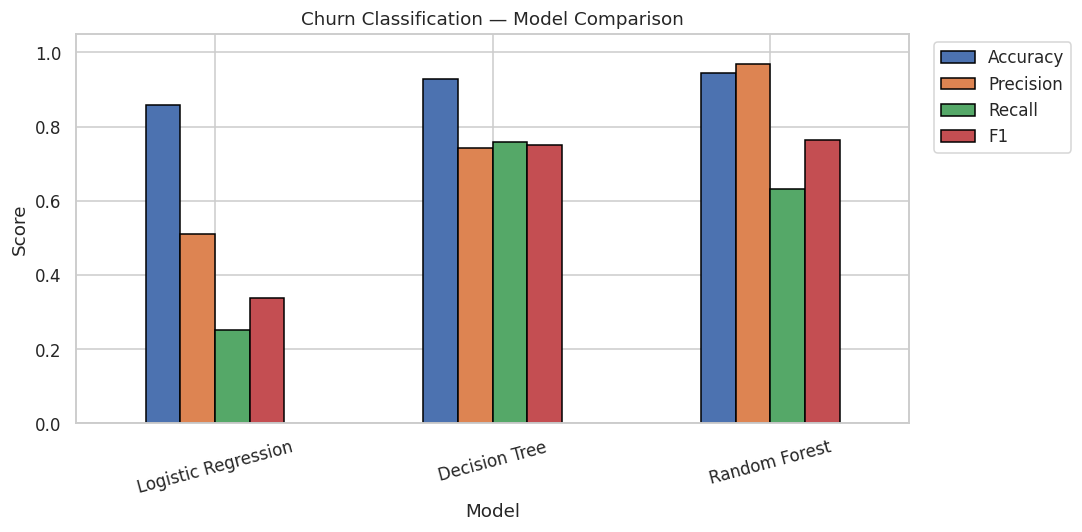

In [5]:
# Compare models visually
ax = results.plot(kind='bar', figsize=(10, 5), edgecolor='black')
ax.set_title("Churn Classification — Model Comparison")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUT / "clf_model_comparison.png", bbox_inches='tight')
plt.show()

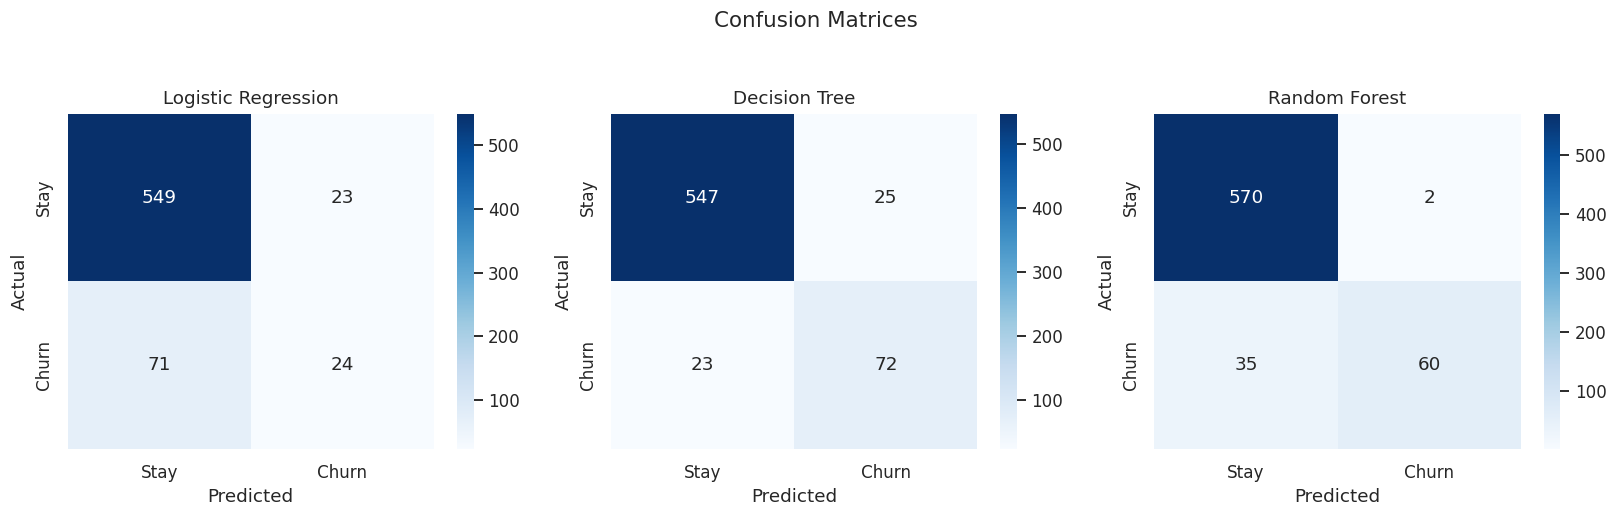

In [6]:
# Confusion matrices for each model
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.suptitle("Confusion Matrices", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(OUT / "clf_confusion_matrices.png", bbox_inches='tight')
plt.show()

In [7]:
# Hyperparameter tuning of the best model (Random Forest) via grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))

best = grid.best_estimator_
p = best.predict(X_test_s)
print("\nTuned Random Forest on test set:")
print(f"  Accuracy : {accuracy_score(y_test, p):.4f}")
print(f"  Precision: {precision_score(y_test, p):.4f}")
print(f"  Recall   : {recall_score(y_test, p):.4f}")
print(f"  F1       : {f1_score(y_test, p):.4f}")

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 : 0.7569

Tuned Random Forest on test set:
  Accuracy : 0.9505
  Precision: 0.9844
  Recall   : 0.6632
  F1       : 0.7925


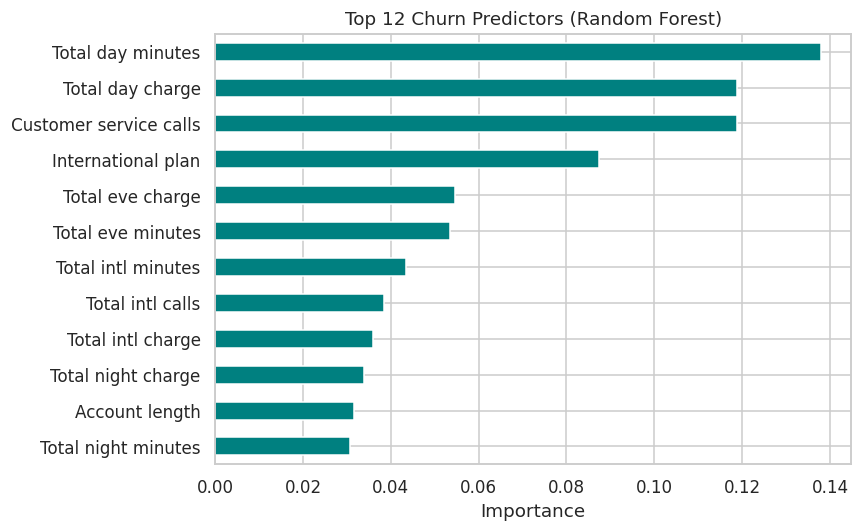

In [8]:
# Top feature importances from the tuned model
importances = pd.Series(best.feature_importances_, index=X_train.columns)
top = importances.sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 5))
top.sort_values().plot(kind='barh', color='teal')
plt.title("Top 12 Churn Predictors (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT / "clf_feature_importance.png", bbox_inches='tight')
plt.show()

**Classification summary:** Random Forest is the strongest model (highest F1). Grid
search tunes it further. The most predictive churn signals are typically
**Customer service calls**, **Total day minutes/charge**, and **International plan** —
actionable levers for a retention team.

---
## Task 3 — NLP Sentiment Analysis

**Dataset:** the cleaned social-media text from Level 1 (`../Level-1/cleaned_sentiment.csv`,
with a fallback to re-cleaning the raw file). Workflow: preprocess text
(tokenize, remove stopwords, lemmatize) → score sentiment with TextBlob → visualize the
sentiment distribution and word clouds.

In [9]:
import nltk, re
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Prefer the Level-1 cleaned file; otherwise load + minimally clean the raw file.
clean_path = Path("../Level-1/cleaned_sentiment.csv")
if clean_path.exists():
    df = pd.read_csv(clean_path)
else:
    df = pd.read_csv(DATA_DIR / "3) Sentiment dataset.csv")
    df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])
    df['Text'] = df['Text'].astype(str).str.strip()
print("Rows:", len(df))
df[['Text']].head(3)

Rows: 710


,Text
0,Enjoying a beautiful day at the park!
1,Traffic was terrible this morning.
2,Just finished an amazing workout! 💪


In [10]:
# Text preprocessing: lowercase, strip non-letters, tokenize, remove stopwords, lemmatize
stop = set(stopwords.words('english'))
lem = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    tokens = word_tokenize(text)
    tokens = [lem.lemmatize(t) for t in tokens if t not in stop and len(t) > 2]
    return tokens

df['tokens'] = df['Text'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: " ".join(t))
df[['Text', 'clean_text']].head(3)

,Text,clean_text
0,Enjoying a beautiful day at the park!,enjoying beautiful day park
1,Traffic was terrible this morning.,traffic terrible morning
2,Just finished an amazing workout! 💪,finished amazing workout


In [11]:
# Sentiment scoring with TextBlob (polarity -> Positive / Negative / Neutral)
from textblob import TextBlob

def polarity_class(text):
    p = TextBlob(text).sentiment.polarity
    if p > 0.05:  return 'Positive'
    if p < -0.05: return 'Negative'
    return 'Neutral'

df['tb_polarity'] = df['Text'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
df['tb_sentiment'] = df['Text'].apply(polarity_class)
print(df['tb_sentiment'].value_counts())

tb_sentiment
Neutral     330
Positive    263
Negative    117
Name: count, dtype: int64


In [12]:
# If the cleaned file carries the canonical Sentiment_Class label, compare against TextBlob
if 'Sentiment_Class' in df.columns:
    agree = (df['Sentiment_Class'] == df['tb_sentiment']).mean()
    print(f"Agreement between dataset labels and TextBlob: {agree:.1%}")
    print(pd.crosstab(df['Sentiment_Class'], df['tb_sentiment']))
else:
    print("No reference label column available; using TextBlob output only.")

Agreement between dataset labels and TextBlob: 50.8%
tb_sentiment     Negative  Neutral  Positive
Sentiment_Class                             
Negative               34       35         5
Neutral                68      201       132
Positive               15       94       126


/tmp/claude-1000/ipykernel_3754/2313062183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tb_sentiment', order=order,


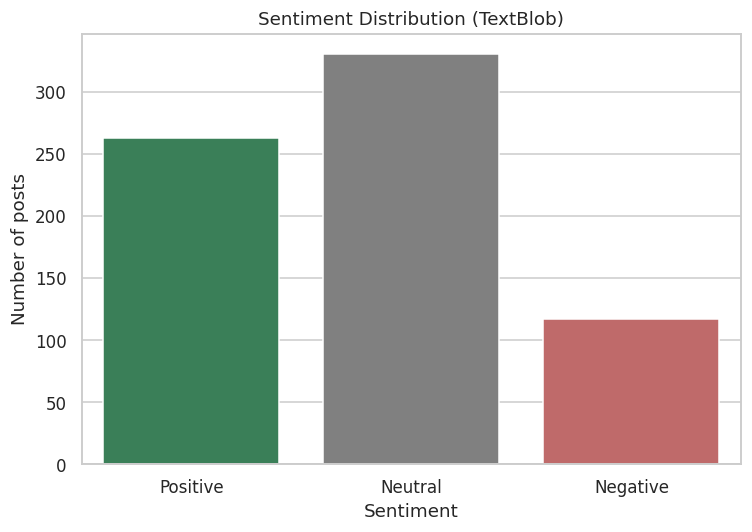

In [13]:
# Sentiment distribution bar chart
plt.figure(figsize=(7, 5))
order = ['Positive', 'Neutral', 'Negative']
sns.countplot(data=df, x='tb_sentiment', order=order,
              palette={'Positive':'seagreen','Neutral':'gray','Negative':'indianred'})
plt.title("Sentiment Distribution (TextBlob)")
plt.xlabel("Sentiment"); plt.ylabel("Number of posts")
plt.tight_layout()
plt.savefig(OUT / "nlp_sentiment_distribution.png", bbox_inches='tight')
plt.show()

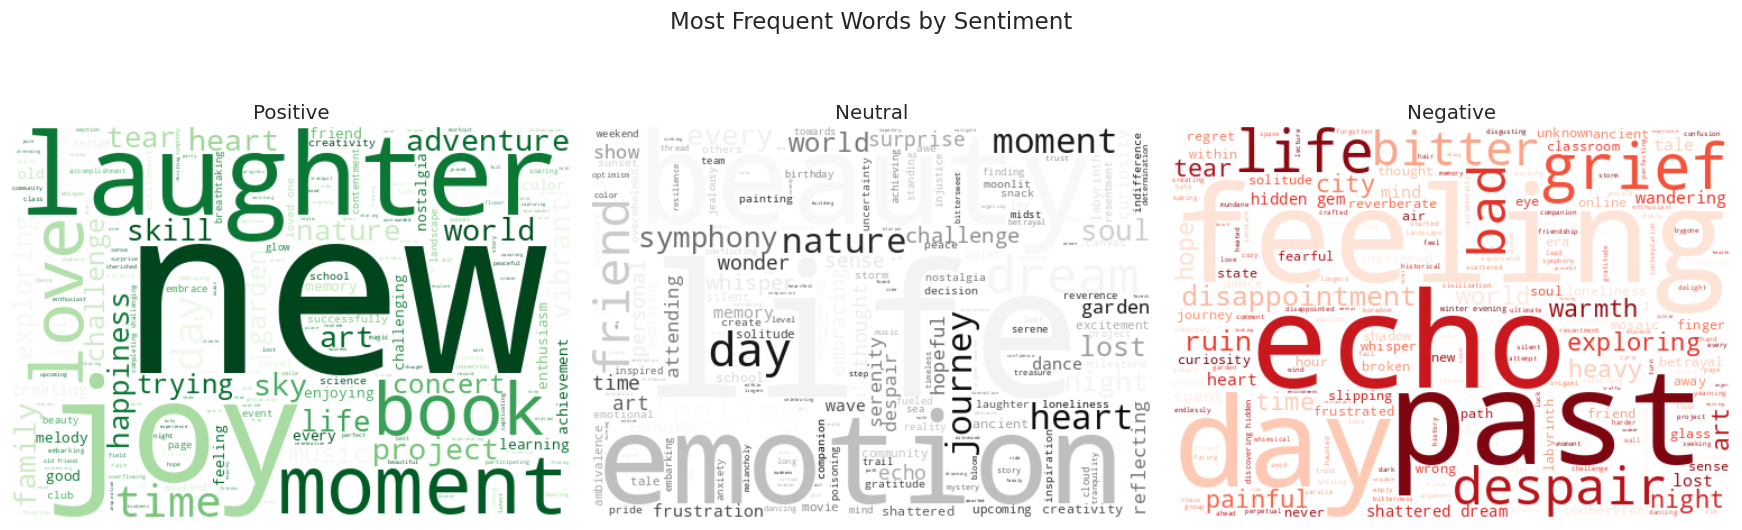

In [14]:
# Word clouds per sentiment class
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = {'Positive':'Greens', 'Neutral':'Greys', 'Negative':'Reds'}
for ax, sentiment in zip(axes, order):
    text = " ".join(df.loc[df['tb_sentiment'] == sentiment, 'clean_text'])
    ax.set_title(f"{sentiment}", fontsize=13)
    ax.axis('off')
    if text.strip():
        wc = WordCloud(width=500, height=350, background_color='white',
                       colormap=cmaps[sentiment]).generate(text)
        ax.imshow(wc, interpolation='bilinear')
fig.suptitle("Most Frequent Words by Sentiment", y=1.03, fontsize=15)
fig.tight_layout()
fig.savefig(OUT / "nlp_wordclouds.png", bbox_inches='tight')
plt.show()

/tmp/claude-1000/ipykernel_3754/1026546559.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq, y='word', x='count', palette='viridis')


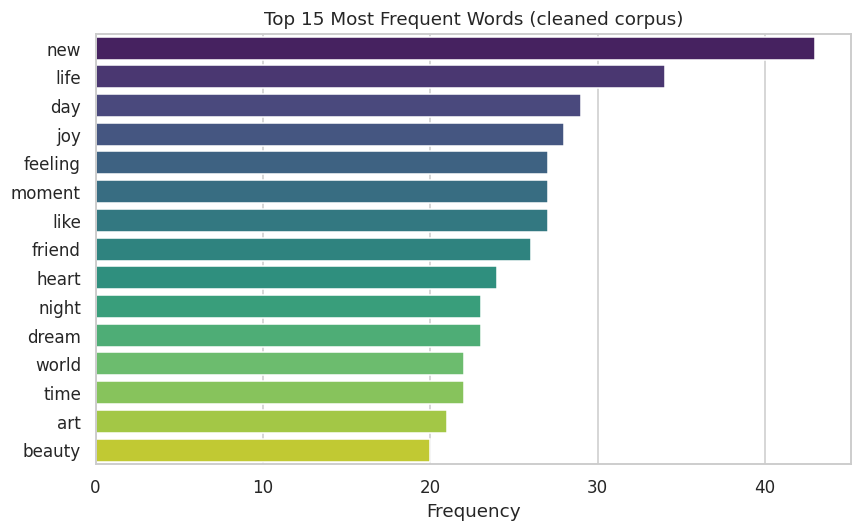

In [15]:
# Overall most frequent words across the corpus
from collections import Counter
all_tokens = [t for toks in df['tokens'] for t in toks]
common = Counter(all_tokens).most_common(15)
freq = pd.DataFrame(common, columns=['word', 'count'])
plt.figure(figsize=(8, 5))
sns.barplot(data=freq, y='word', x='count', palette='viridis')
plt.title("Top 15 Most Frequent Words (cleaned corpus)")
plt.xlabel("Frequency"); plt.ylabel("")
plt.tight_layout()
plt.savefig(OUT / "nlp_word_frequency.png", bbox_inches='tight')
plt.show()

**NLP summary:** text was tokenized, stopword-filtered and lemmatized, then scored with
TextBlob into Positive/Neutral/Negative. The distribution skews positive, and the word
clouds surface the characteristic vocabulary of each sentiment class.

---
### Level 3 complete ✅
Classification + NLP figures in `outputs/`; interactive dashboard in `dashboard/`.